# Geospatial Data Science - EEPS 440/460

# Lecture 3

# Numpy Arrays

# Motivation: Climate Reanalysis Data (ERA-Interim)

Reanalysis is a scientific method for developing a comprehensive record of how weather and climate are changing over time. In it, observations and a numerical model that simulates one or more aspects of the Earth system are combined objectively to generate a synthesized estimate of the state of the system. (Source: https://reanalyses.org)

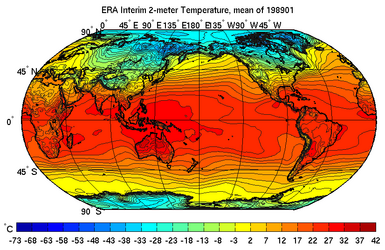

ERA-Interim is a global atmospheric reanalysis from 1979 until 31 August 2019. The spatial resolution of the data set is approximately 80 km (T255 spectral) on 60 vertical levels from the surface up to 0.1 hPa. 

## Let's look at some output from ERA-Interim

In [ ]:
file = '/eeps440/data/era-interim/era_interim_monthly_197901_201512_upscaled.nc'

To read this file we are going to need to import the netCDF4 package

In [2]:
import numpy as np
import netCDF4 as nc
import datetime

Open access to the file

In [3]:
fp = nc.Dataset(file)

Let's look at what variables this file contains

In [4]:
print(fp.variables.keys())

dict_keys(['albedo_sfc', 'blh', 'cape', 'd2m', 'evap', 'evap_snow', 'height_sfc', 'hi_cld', 'land_mask', 'lat', 'lhflx', 'lo_cld', 'lon', 'lwflx', 'lwflx_dn', 'mid_cld', 'netflx', 'p_msl', 'p_sfc', 'precip', 'precip_conv', 'precip_ls', 'precip_snow', 'precip_snow_conv', 'precip_snow_ls', 'rh2m', 'runoff', 'shflx', 'swflx', 'swflx_dn', 't2m', 't_skin', 'tau_x', 'tau_y', 'tciw', 'tclw', 'tcw', 'tcwv', 'time', 'time_bnds', 'tot_cld', 'wspd10'])


Let's look at the variable `t2m`

In [5]:
data = fp['t2m'][:]
print(data.shape)

(444, 180, 288)


Which Python type is this data?

In [6]:
print(type(data))

<class 'numpy.ma.MaskedArray'>


This is a 3-dimensional numpy array. Think of it as a fancy "list of lists of lists". 

But what do the dimensions represent?

In [7]:
print(fp['t2m'])

<class 'netCDF4.Variable'>
float32 t2m(time, lat, lon)
    long_name: temperature at 2m
    units: degC
    _FillValue: -1e+34
    missing_value: -1e+34
    history: From /dev/shm/monthly_an_sfc.nc
unlimited dimensions: time
current shape = (444, 180, 288)
filling on


The dimensions are variables themselves. Let's look at them.

In [8]:
lats = fp['lat'][:]
print(lats[0:5],lats[-5:])

[-89.5 -88.5 -87.5 -86.5 -85.5] [85.5 86.5 87.5 88.5 89.5]


In [9]:
lons = fp['lon'][:]
print(lons[0:5],lons[-5:])

[0.625     1.8728299 3.1206598 4.3684897 5.6163197] [353.76086 355.00867 356.2565  357.50433 358.75217]


In [10]:
times = fp['time']
print(times[0:5],times[-5:])

[ 15.5  45.   74.5 105.  135.5] [13376.5 13407.  13437.5 13468.  13498.5]


We can actually directly convert these timestamps to a datetime array.

For this conversion, we use the function `num2date` in the netCDF4 package.

In [11]:
dates = nc.num2date(times[:],units=times.units,calendar=times.calendar)
print(dates[0:5])

[cftime.DatetimeGregorian(1979, 1, 16, 12, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(1979, 2, 15, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(1979, 3, 16, 12, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(1979, 4, 16, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(1979, 5, 16, 12, 0, 0, 0, has_year_zero=False)]


## Climate and Forecast (CF) Conventions

The CF Conventions standardize metadata for earth science data, particularly in netCDF format, ensuring datasets are self-describing and facilitating interoperability across platforms and disciplines. Learn more about it [here](https://cfconventions.org/cf-conventions/cf-conventions.html)

### Key Components

1. **Standard Names**:
   - Provides a controlled vocabulary for physical quantities, ensuring consistent variable naming across datasets.

2. **Coordinate Systems**:
   - Defines conventions for specifying spatial (latitude, longitude, vertical) and temporal coordinates, enabling precise geolocation of data points.

3. **Grid Mappings**:
   - Describes methods for representing different grid types and projections, supporting accurate spatial referencing.

4. **Cell Methods and Measures**:
   - Specifies how statistical operations and measurements are recorded, providing clarity on data representation and aggregation methods.

5. **Attributes**:
   - Outlines metadata attributes such as units, long names, and descriptions, ensuring comprehensive documentation of dataset contents.

Adhering to CF Conventions enhances the usability and longevity of datasets, promoting effective data exchange and collaboration.

In [12]:
dates = nc.num2date(times[:],units=times.units,calendar=times.calendar,only_use_cftime_datetimes=False)
print(dates[0:5])

[real_datetime(1979, 1, 16, 12, 0) real_datetime(1979, 2, 15, 0, 0)
 real_datetime(1979, 3, 16, 12, 0) real_datetime(1979, 4, 16, 0, 0)
 real_datetime(1979, 5, 16, 12, 0)]


Let's have some fun and look at the monthly average temperature over Houston, TX from 1979 to present.

First, we need to identify the pixel indices that most closely match those of Houston.

In [13]:
import numpy as np
lat_houston = 29.717154
lon_houston = 360-95.4041

#Look for the closest grid cell center
ilat = np.argmin(np.abs(lats - lat_houston))
ilon = np.argmin(np.abs(lons - lon_houston))
print(ilat,ilon)

119 212


Let's extract the data for this region

In [14]:
data_houston = data[:,ilat,ilon]
print(data_houston.shape)

(444,)


Import matplotlib so we can create some plots.

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

In [16]:
# Optional - you can make your plots nicer with styles
# List available styles
print(plt.style.available)
# Use a popular style
plt.style.use('seaborn-v0_8-darkgrid')  # Example of a good style

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


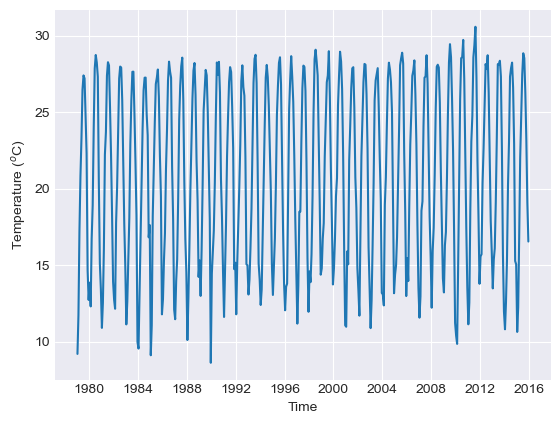

In [17]:
plt.plot(dates,data_houston)
plt.xlabel('Time')
plt.ylabel('Temperature ($^o$C)')
plt.show()

Let's now show a map of the last time stamp

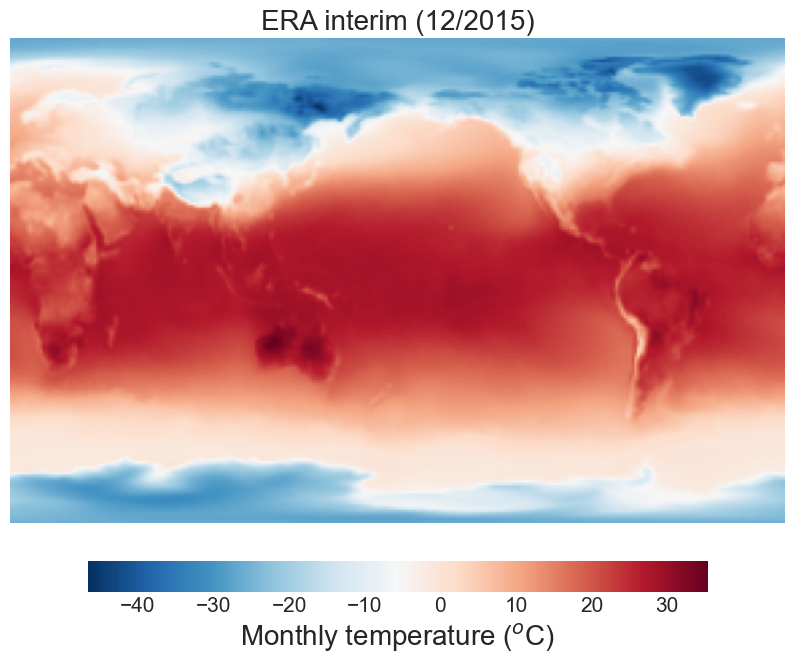

In [18]:
plt.figure(figsize=(10,10))
plt.imshow(np.flipud(data[-1,:,:]),cmap=plt.get_cmap('RdBu_r'))
plt.axis('off')
plt.title('ERA interim (%02d/%04d)' % (dates[-1].month,dates[-1].year),fontsize=20)
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.05)
cb.ax.tick_params(labelsize=15)
cb.set_label('Monthly temperature ($^o$C)',fontsize=20)
plt.show()

Let's average across all 2015.

We start by defining a Boolean mask to find the timestamps that are in 2015.

In [19]:
m = (dates >= datetime.datetime(2015,1,1)) & (dates <= datetime.datetime(2015,12,31))

Let's now compute the 2015 mean per pixel.

In [20]:
data_2015_average = np.mean(data[m,:,:],axis=0)

Let's plot the resulting map as well.

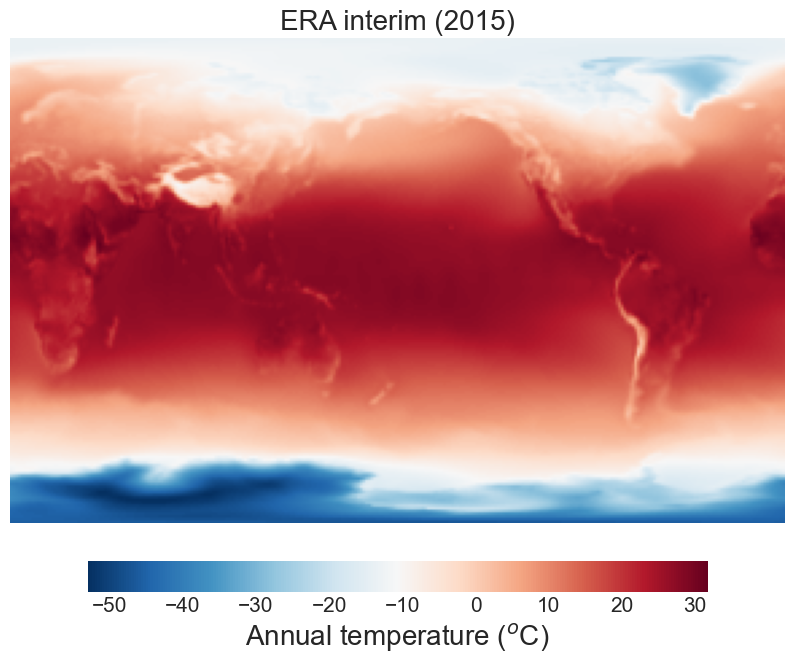

In [21]:
plt.figure(figsize=(10,10))
plt.imshow(np.flipud(data_2015_average),cmap=plt.get_cmap('RdBu_r'))
plt.axis('off')
plt.title('ERA interim (%02d)' % (2015),fontsize=20)
cb = plt.colorbar(orientation='horizontal',shrink=0.8,pad=0.05)
cb.ax.tick_params(labelsize=15)
cb.set_label('Annual temperature ($^o$C)',fontsize=20)
plt.show()

Let's finish up by averaging across all longitudes to get the latitudinal profile for 2015

In [22]:
data_2015_average_lat_profile = np.mean(data_2015_average,axis=1)

And then make a corresponding plot. 

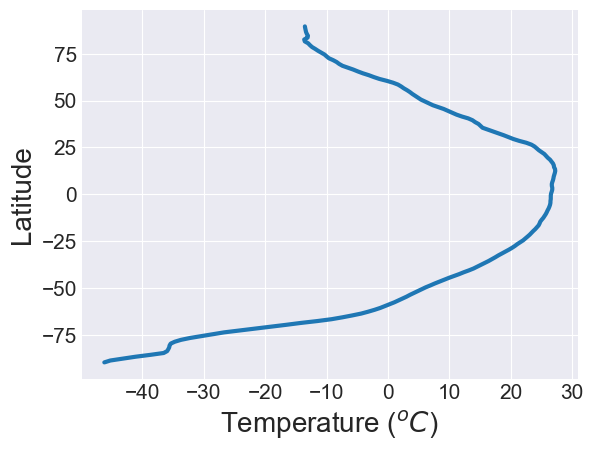

In [23]:
plt.plot(data_2015_average_lat_profile,  lats,lw=3)
plt.ylabel('Latitude',fontsize=20)
plt.xlabel('Temperature ($^oC$)',fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

In [24]:
#Close the file pointer
fp.close()

I hope that helped motivate what we are doing in this class. Before we dive into working with spatial data, we need to continue working on our basic skills. And the key step now is to learn about how to work with multi-dimensional arrays in Python (i.e., NumPy).

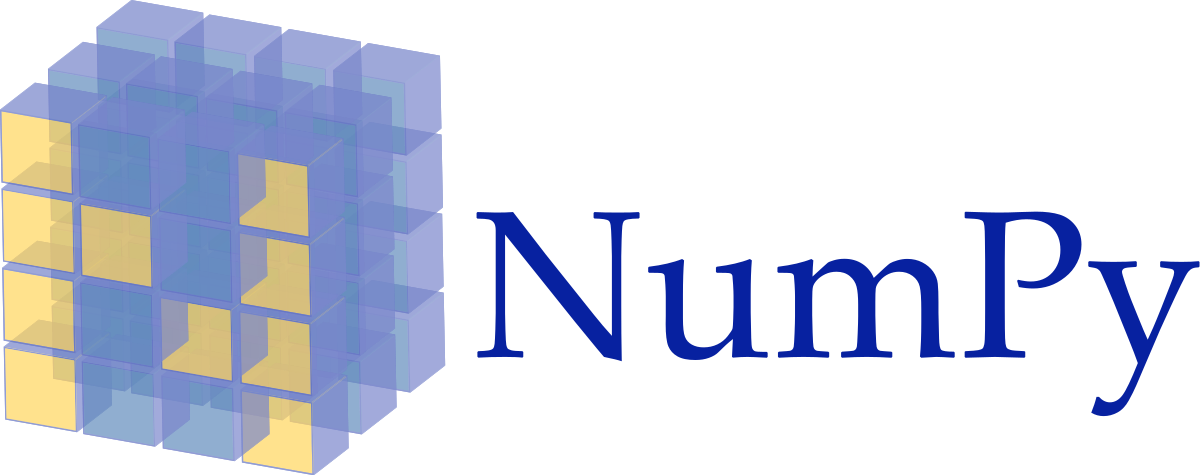

The following NumPy lecture is adapted from the Scipy lecture notes (https://scipy-lectures.org/). For more information, I encourage you to check out the full tutorial online.

## What is Numpy?

* Extension package to Python for multi-dimensional arrays
* Closer to hardware (efficiency)
* Designed for scientific computation (convenience)
* Also known as array oriented computing

Note: NumPy gives Python a Matlab/Fortran feel. Experience with these languages makes the switch to NumPy fairly straightforward (except for the 0-based indexing!).

## List vs. Array

In [25]:
#Numpy is usually imported as np
import numpy as np

In [26]:
Alist = [1,2,3,4,5]
print(type(Alist))
print(Alist)

<class 'list'>
[1, 2, 3, 4, 5]


In [27]:
Aarray = np.array([1,2,3,4,5])
print(type(Aarray))
print(Aarray)

<class 'numpy.ndarray'>
[1 2 3 4 5]


You can also just take an existing list and convert it to an array.

In [28]:
Aarray = np.array(Alist)
print(type(Aarray))

<class 'numpy.ndarray'>


## NumPy basics: numpy.ndarray class

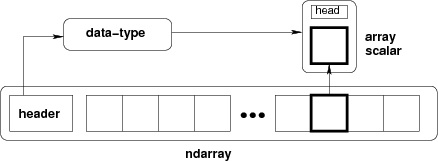

This is most important object defined in NumPy. It describes the collection of items of the same type. Items in the collection can be accessed using a zero-based index.

Source: https://www.tutorialspoint.com/numpy/numpy_ndarray_object.htm

## Why are NumPy arrays useful?
Memory-efficient container that provides fast numerical operations (orders of magnitude speed-up).

In [29]:
#Squaring values using list comprehensions
L = range(1000)
%timeit [i**2 for i in range(1000)]

19.4 μs ± 274 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [30]:
#Squaring values using numpy arrays 
a = np.arange(1000)
%timeit a**2

457 ns ± 26.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Note: For more information on `%timeit` go [here](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit).

## Creating arrays: Manually

In [31]:
#1-dimensional
test = np.array([1,2,3,4,5])
print(test)

[1 2 3 4 5]


In [32]:
#2-dimensional
test = np.array([[1,3],[2,4]])
print(test)

[[1 3]
 [2 4]]


There is no limit on the number of dimensions

## Creating arrays: Functions

### np.arange()

In [33]:
A = np.arange(5)
print(A)

[0 1 2 3 4]


In [34]:
B = np.arange(0, 5, 2) # populate an array counting from 0 to 5 every 2 elements.
print(B.shape)
print(B)

(3,)
[0 2 4]


In [35]:
#We could use slicing like we do with lists
print(A[::2])

[0 2 4]


### np.linspace()

In [36]:
A = np.linspace(1,2,11) # start, end, num-points
print(A)

[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]


In [37]:
B = np.linspace(1,2,10, endpoint=False)
print(B)


[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9]


### np.ones()

In [38]:
A = np.ones((2,2))  # reminder: (2, 2) is a tuple
print(A)

[[1. 1.]
 [1. 1.]]


### np.zeros()

In [39]:
A = np.zeros((10,1))
print(A)

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


### np.diag()

In [40]:
A = np.diag(np.linspace(0,1,3))
print(A)

[[0.  0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  1. ]]


### np.rand()

In [41]:
A = np.random.rand(3,3)
print(A)

[[0.73228853 0.81532981 0.65749976]
 [0.34815839 0.8376514  0.34692237]
 [0.90266649 0.90914143 0.91791631]]


## NumPy array methods and variables

Each NumPy array is an instance of the class `np.ndarray`. As such it has its own methods (e.g., `A.mean()`) and variables (e.g., `A.shape`). Here are some basic examples. We will explore more later on. 

In [42]:
np.random.seed(1)
A = np.random.rand(3,3)
print(A)

[[4.17022005e-01 7.20324493e-01 1.14374817e-04]
 [3.02332573e-01 1.46755891e-01 9.23385948e-02]
 [1.86260211e-01 3.45560727e-01 3.96767474e-01]]


In [43]:
print(A.shape)

(3, 3)


In [44]:
print(A.T) #transpose

[[4.17022005e-01 3.02332573e-01 1.86260211e-01]
 [7.20324493e-01 1.46755891e-01 3.45560727e-01]
 [1.14374817e-04 9.23385948e-02 3.96767474e-01]]


In [45]:
print(A.mean())

0.289719593759024


Want to learn more? https://docs.scipy.org/doc/numpy/reference/arrays.ndarray.html

## Array shape manipulation

In [46]:
A = np.arange(16)
print(A)
print(A.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16,)


### Reshaping

In [47]:
B = np.reshape(A,(4,4))
print(B)
print(B.shape)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
(4, 4)


### Flattening

In [48]:
C = B.ravel()
print(C)
print(C.shape)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
(16,)


### Add dimensions

In [49]:
D = C[:,np.newaxis]
print(D.shape)

(16, 1)


In [50]:
E = D[:,:,np.newaxis]
print(E.shape)

(16, 1, 1)


## Combining arrays

### Stacking arrays

In [51]:
A = np.ones(4)
B = np.arange(4)
print(A)
print(B)

[1. 1. 1. 1.]
[0 1 2 3]


In [52]:
C = np.stack((A,B),axis=1)
print(C)

[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]


In [53]:
C = np.stack((A,B),axis=0)
print(C)

[[1. 1. 1. 1.]
 [0. 1. 2. 3.]]


### Concatenating arrays

In [54]:
A = np.ones(4)
B = np.arange(4)
print(A)
print(B)

[1. 1. 1. 1.]
[0 1 2 3]


In [55]:
C = np.concatenate((A,B))
print(C)

[1. 1. 1. 1. 0. 1. 2. 3.]


## NumPy datatypes

In [56]:
A = np.zeros((2,2),dtype=np.float32)
print(A)
print(A.dtype)

[[0. 0.]
 [0. 0.]]
float32


In [57]:
A = np.zeros((2,2),dtype=np.int32)
print(A)
print(A.dtype)

[[0 0]
 [0 0]]
int32


And many, many more...

## Indexing and slicing

Everything that we learned about accessing lists elements applies to arrays (and much more).

In [58]:
A = np.linspace(0,1,11)
print(A)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [59]:
print(A[-2])

0.9


In [60]:
print(A[::3])

[0.  0.3 0.6 0.9]


## Indexing and slicing: Multiple dimensions

In [61]:
A = np.diag(np.arange(1,6))
#print(A)
A = np.arange(16).reshape((4,4))
print(A)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


In [62]:
print(A[0,3])

3


In [63]:
print(A[2,:])

[ 8  9 10 11]


In [64]:
print(A[1:3,1:3])

[[ 5  6]
 [ 9 10]]


## Indexing and slicing: Examples

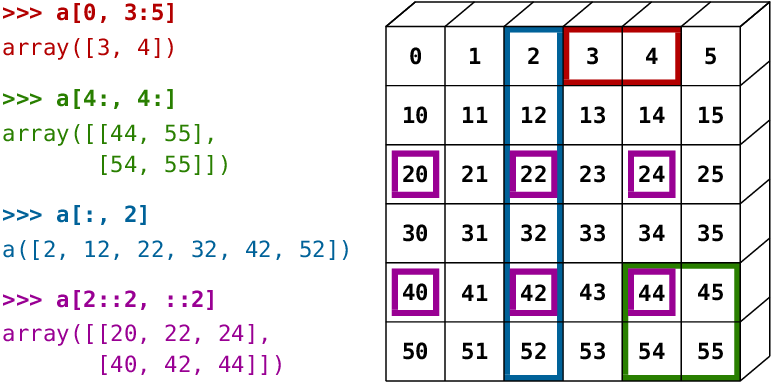

Source: https://scipy-lectures.org/intro/numpy/array_object.html#what-are-numpy-and-numpy-arrays

## Fancy indexing

NumPy arrays can be indexed with slices, but also with boolean or integer arrays (masks). This method is called fancy indexing. It creates copies of the subsetted data.

## Fancy indexing: Boolean masks

In [65]:
np.random.seed(5) #We use a seed to ensure that the random draw is always the same
A = np.random.randint(0, 21, 5)
print(A)

[ 3 14 15  6 16]


In [66]:
mask = A > 7
print(mask)

[False  True  True False  True]


In [67]:
#Extract the values that satisfy that condition
print(A[mask])

[14 15 16]


In [68]:
#Extract the values that do not satisfy that condition
print(A[~mask])

[3 6]


## Combining multiple Boolean masks

In [69]:
print(A)

[ 3 14 15  6 16]


In [70]:
m1 = A >= 15 
m2 = A < 6
print(m1)
print(m2)

[False False  True False  True]
[ True False False False False]


In [71]:
mask = m1 | m2
print(mask)

[ True False  True False  True]


In [72]:
print(A[mask])

[ 3 15 16]


## Combining multiple Boolean masks (even easier!)

In [73]:
print(A)

[ 3 14 15  6 16]


In [74]:
mask = (A >= 15) | (A < 6)
print(mask)

[ True False  True False  True]


In [75]:
print(A[mask])

[ 3 15 16]


Boolean masks are your friend and will save you a lot of time.

## Using Boolean masks to insert new information

In [76]:
print(A)
print(mask)

[ 3 14 15  6 16]
[ True False  True False  True]


In [77]:
A[mask] = 10
print(A)

[10 14 10  6 10]


In [78]:
A[~mask] = 20
print(A)

[10 20 10 20 10]


## np.where: Back out the indices from the Boolean mask

In [79]:
np.random.seed(5) #We use a seed to ensure that the random draw is always the same
A = np.random.randint(0, 21, 5)
print(A)

[ 3 14 15  6 16]


In [80]:
mask = (A >= 15) | (A < 6)
print(mask)

[ True False  True False  True]


In [81]:
idx = np.where(mask)
print(idx)

(array([0, 2, 4]),)


In [82]:
print(A[idx])

[ 3 15 16]


## Fancy indexing: Indexing with an array of integers

In [83]:
#Let's initialize another array
np.random.seed(10) #We use a seed to ensure that the random draw is always the same
A = np.random.randint(0, 21, 5)
print(A)

[ 9  4 15  0 17]


Indexing can be done with an array of integers, where the same index is repeated several times:

In [84]:
B = A[[0,2,0]]
print(B)

[ 9 15  9]


New values can also be assigned with integer indexing:

In [85]:
A[[0,3]] = -1
print(A)

[-1  4 15 -1 17]


When a new array is created by indexing with an array of integers, the new array has the same shape as the array of integers:

In [86]:
B = A[[4,0,4]]
print(B.shape)

(3,)


## Fancy indexing: Examples

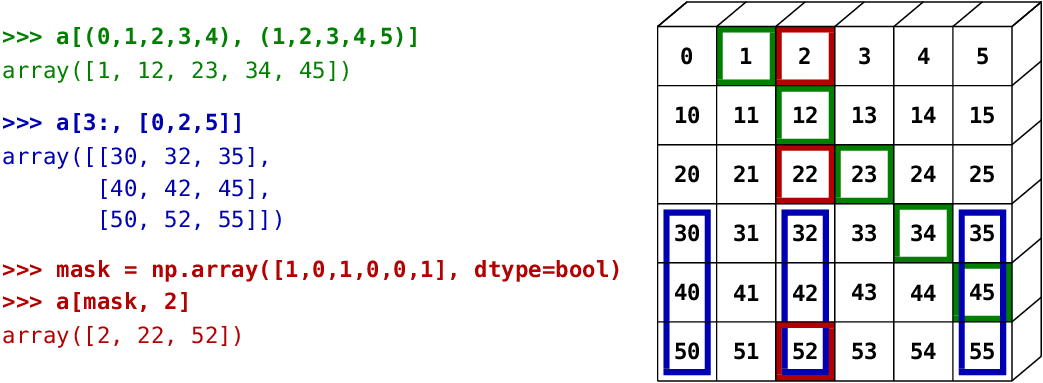

Source: https://scipy-lectures.org/intro/numpy/array_object.html#what-are-numpy-and-numpy-arrays

# Numerical operations on arrays

## Element-wise operations: Scalars and arrays

In [87]:
A = np.arange(5)
b = 2.0

In [88]:
C = b*A
print(C)

[0. 2. 4. 6. 8.]


In [89]:
C = A + b
print(C)

[2. 3. 4. 5. 6.]


In [90]:
C = A % b
print(C)

[0. 1. 0. 1. 0.]


## Element-wise operations: Arrays and arrays

In [91]:
A = np.arange(5)
B = 2*np.ones(5)
print(A)
print(B)

[0 1 2 3 4]
[2. 2. 2. 2. 2.]


In [92]:
C = A + B
print(C)

[2. 3. 4. 5. 6.]


In [93]:
C = A / B
print(C)

[0.  0.5 1.  1.5 2. ]


In [94]:
C = A ** B
print(C)

[ 0.  1.  4.  9. 16.]


## Why not just iterate? Because it is much faster

In [95]:
def elementwise_addition(A,B):
    C = np.zeros(A.size)
    for i in range(C.size):
        C[i] = A[i] + B[i]
    return(C)

In [96]:
A = np.arange(500)
B = 2*np.ones(500)

In [97]:
#Iteration approach
%timeit C = elementwise_addition(A,B)

72 μs ± 2.1 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [98]:
#Numpy elementwise operation
%timeit C = A + B

543 ns ± 27.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


## Element-wise operations: Comparisons

In [99]:
A = np.array([2,3,0,1,2])
B = np.array([5,3,1,1,0])

In [100]:
mask = A == B
print('Mask:',mask)
print('Number of True elements:',np.sum(mask))

Mask: [False  True False  True False]
Number of True elements: 2


In [101]:
mask = A >= B
print('Mask:',mask)
print('Number of elements where A >= B:',np.sum(mask))

Mask: [False  True False  True  True]
Number of elements where A >= B: 3


## Element-wise operations: Transcendental functions

In [102]:
A = np.linspace(1,2,10)
print(A)

[1.         1.11111111 1.22222222 1.33333333 1.44444444 1.55555556
 1.66666667 1.77777778 1.88888889 2.        ]


In [103]:
B = np.log(A)
print(B)

[0.         0.10536052 0.2006707  0.28768207 0.36772478 0.44183275
 0.51082562 0.57536414 0.63598877 0.69314718]


In [104]:
B = np.exp(A)
print(B)

[2.71828183 3.03773178 3.39472319 3.79366789 4.23949621 4.73771786
 5.29449005 5.91669359 6.61201791 7.3890561 ]


In [105]:
B = np.sin(A)
print(B)

[0.84147098 0.8961922  0.93986069 0.9719379  0.99202822 0.99988386
 0.99540796 0.9786557  0.94983371 0.90929743]


## Basic reductions I

In [106]:
A = np.linspace(1,2,10)
print(A)

[1.         1.11111111 1.22222222 1.33333333 1.44444444 1.55555556
 1.66666667 1.77777778 1.88888889 2.        ]


In [107]:
b = np.sum(A)
print(b)

15.0


In [108]:
b = A.sum()
print(b)

15.0


Point: Either way works

## Basic reductions II

In [109]:
b = np.mean(A)
print(b)

1.5


In [110]:
b = np.max(A)
print(b)

2.0


In [111]:
idx = np.argmax(A) #Gives you the index of the max value (also could use argmin)
print(idx,A[idx])

9 2.0


In [112]:
b = np.std(A)
print(b)

0.31914236925211265


## Reductions: Multiple dimensions

In [113]:
A = np.linspace(1,10,100).reshape(10,10)
print('Dimensions of A:',A.shape)

Dimensions of A: (10, 10)


In [114]:
#Mean of the entire array
print(np.mean(A))

5.5


In [115]:
#Mean along the 1st dimension
print(np.mean(A,axis=0))

[5.09090909 5.18181818 5.27272727 5.36363636 5.45454545 5.54545455
 5.63636364 5.72727273 5.81818182 5.90909091]


In [116]:
#Mean along the 2nd dimension
print(np.mean(A,axis=1))

[1.40909091 2.31818182 3.22727273 4.13636364 5.04545455 5.95454545
 6.86363636 7.77272727 8.68181818 9.59090909]


## Broadcasting
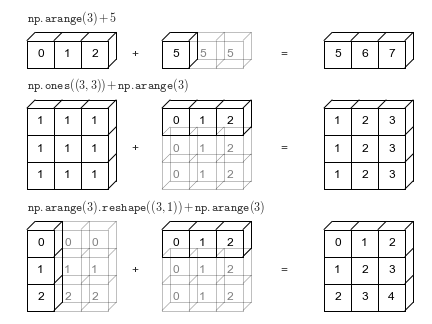

We are not going to go into the details (it gets confusing very quickly). However, broadcasting is a very powerful technique and I recommend you learn more about it [here](https://scipy-lectures.org/intro/numpy/operations.html#broadcasting). 

It sometimes feels like magic hence the confusion.

## Miscellanous numpy functions

### np.unique()

It extracts all the unique values in an array

In [117]:
A = np.random.randint(0,2,10) # 10 random integer elements between 0 and up to 1
print(A)
print(np.unique(A))

[1 0 1 1 0 1 1 0 0 1]
[0 1]


And that's all for the introduction to NumPy. However, there is much more to learn. For everything NumPy go to https://numpy.org/. NumPy arrays are going to be in almost everything that we do in this course, so aim to be comfortable with all things NumPy. This week's assignment should help but it takes a while before it becomes second nature.   